# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica y se aplica a dos diferentes datasets.

# Laboratorio N° 3: Regresión Logística Binaria para la Predicción de Incumplimiento de Tarjetas de Crédito

**Dataset Utilizado:** Default of Credit Card Clients Dataset (UCI Machine Learning Repository)
* **Número de Filas (Ejemplos - $m$):** 30,000 ejemplos (Cumple con $m \ge 20000$)
* **Número de Columnas (Propiedades - $n$):** 23 características independientes y 1 columna objetivo (Cumple con $n \ge 5$)
* **Tipo de Clasificación:** Binaria (0 = Pagó a tiempo, 1 = Incumplió el pago)

### Descripción de las Columnas del Dataset:
1. **ID**: Identificador único de cada cliente (Se eliminará ya que no aporta valor predictivo).
2. **LIMIT_BAL**: Monto del crédito otorgado en dólares de Taiwán (NT).
3. **SEX**: Género (1 = Masculino, 2 = Femenino).
4. **EDUCATION**: Nivel educativo (1 = Escuela de posgrado, 2 = Universidad, 3 = Escuela secundaria, 4 = Otros).
5. **MARRIAGE**: Estado civil (1 = Casado, 2 = Soltero, 3 = Otros).
6. **AGE**: Edad del cliente en años.
7. **PAY_0 a PAY_6**: Historial de estado de pago mensual de abril a septiembre de 2005 (-1 = Pago al día, 1 = Retraso de un mes, 2 = Retraso de dos meses, etc.).
8. **BILL_AMT1 a BILL_AMT6**: Monto del estado de cuenta mensual de abril a septiembre de 2005.
9. **PAY_AMT1 a PAY_AMT6**: Monto del pago mensual anterior de abril a septiembre de 2005.
10. **default.payment.next.month (Objetivo)**: Variable binaria a predecir (1 si el cliente incumplió con el pago al mes siguiente, 0 si cumplió).

In [2]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Configuración para que los gráficos se muestren integrados dentro del entorno local
%matplotlib inline

### Explicación de los Comandos Utilizados en la Celda Anterior:
* `import os`: Se utiliza para interactuar con el sistema operativo y gestionar rutas de archivos de manera local.
* `import numpy as np`: Es la librería fundamental para el cálculo matricial y vectorial eficiente en Python. Nos permite realizar operaciones sobre matrices optimizadas.
* `import pandas as pd`: Es la herramienta esencial para el análisis y preprocesamiento de datos estructurados en formato de DataFrame. La utilizaremos para cargar y manipular nuestro archivo CSV.
* `from matplotlib import pyplot as plt`: Es el módulo encargado de la generación de visualizaciones y gráficos estadísticos. Lo utilizaremos para graficar el comportamiento del costo $J(\theta)$.
* `%matplotlib inline`: Es una función mágica de Jupyter que le ordena a Visual Studio Code incrustar los gráficos directamente debajo de la celda de ejecución.

In [3]:
# Carga del dataset desde el archivo local CSV utilizando Pandas
df = pd.read_csv("UCI_Credit_Card.csv")

# Eliminamos la columna ID ya que es solo un índice incremental que no afecta al modelo
df = df.drop(columns=['ID'])

# Visualizar las dimensiones del DataFrame para validar requisitos de laboratorio
print(f"Dimensiones del dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas.")

# Mostrar las primeras 5 filas para inspeccionar visualmente que los datos sean puramente numéricos
df.head()

Dimensiones del dataset cargado: 30000 filas y 24 columnas.


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Explicación de los Comandos Utilizados en la Celda Anterior:
* `pd.read_csv("UCI_Credit_Card.csv")`: Lee el archivo delimitado por comas y lo transforma en un objeto DataFrame indexado.
* `df.drop(columns=['ID'])`: Elimina la columna de identificación del cliente de nuestro conjunto de datos. Esto previene que el algoritmo intente ajustar parámetros $\theta$ para un simple número correlativo.
* `df.shape`: Atributo que devuelve una tupla con las dimensiones de la matriz (filas, columnas). Nos sirve para certificar que contamos con 30,000 muestras y las propiedades requeridas.
* `df.head()`: Método de Pandas que retorna por defecto las primeras 5 filas del DataFrame, permitiéndonos cerciorar que todas las variables son de naturaleza numérica.

In [4]:
# Separar características independientes (X) de la etiqueta binaria objetivo (y)
X_raw = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# Determinación del índice de corte para el split del 80%
m_total = X_raw.shape[0]
limite_entrenamiento = int(m_total * 0.8)

# División manual de los datos sin solapamiento
X_train_raw = X_raw[:limite_entrenamiento, :]
y_train = y_raw[:limite_entrenamiento]

X_test_raw = X_raw[limite_entrenamiento:, :]
y_test = y_raw[limite_entrenamiento:]

print(f"Ejemplos para Entrenamiento (80%): {X_train_raw.shape[0]}")
print(f"Ejemplos para Validación/Prueba (20%): {X_test_raw.shape[0]}")

Ejemplos para Entrenamiento (80%): 24000
Ejemplos para Validación/Prueba (20%): 6000


### Explicación de los Comandos Utilizados en la Celda Anterior:
* `df.iloc[:, :-1].values`: Extrae todas las filas y todas las columnas excepto la última, convirtiéndolas en una matriz pura de NumPy que representará nuestras variables explicativas.
* `df.iloc[:, -1].values`: Slices de Pandas para aislar únicamente la última columna (`default.payment.next.month`), que contiene las etiquetas binarias del modelo.
* `int(m_total * 0.8)`: Calcula cuántos ejemplos corresponden al 80% del total de los datos (en este caso, 24,000 ejemplos) para entrenamiento.
* `X_raw[:limite_entrenamiento, :]` y `X_raw[limite_entrenamiento:, :]`: Segmentación estricta que reserva los primeros 24,000 renglones para la fase de entrenamiento y los restantes 6,000 renglones para la fase de testeo, garantizando que el modelo jamás vea los datos de prueba durante su ajuste.

In [5]:
def normalizarCaracteristicas(X):
    # Calcula la media aritmética de cada propiedad (columna)
    mu = np.mean(X, axis=0)
    # Calcula la desviación estándar de cada propiedad
    sigma = np.std(X, axis=0)
    
    # Aplica la fórmula de normalización estándar Z-score
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos el conjunto de entrenamiento
X_train_norm, mu, sigma = normalizarCaracteristicas(X_train_raw)

# Normalizamos el conjunto de prueba usando los mismos parámetros mu y sigma del entrenamiento para evitar fuga de información
X_test_norm = (X_test_raw - mu) / sigma

# Añadimos la columna de unos (intercepto) a ambas matrices
X_train = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Dimensión final de X de entrenamiento con intercepto: {X_train.shape}")

Dimensión final de X de entrenamiento con intercepto: (24000, 24)


### Explicación de los Comandos Utilizados en la Celda Anterior:
* `np.mean(X, axis=0)` y `np.std(X, axis=0)`: Calculan la media y la desviación estándar por columna (`axis=0`). Esto es crítico debido a que propiedades como `LIMIT_BAL` manejan valores de hasta 100,000 mientras que `SEX` u `AGE` manejan magnitudes muy pequeñas. Sin normalización, el descenso por el gradiente oscilaría bruscamente y fallaría en converger.
* `(X - mu) / sigma`: Aplica un escalado estándar de modo que todas las características se centren en torno a 0 con una varianza igual a 1.
* `np.concatenate([...], axis=1)`: Inserta una columna llena de valores `1` al inicio de las matrices de diseño ($X$). Esto representa matemáticamente la propiedad del término de sesgo o intercepto ($\theta_0$).

In [6]:
def sigmoid(z):
    # Convierte la entrada z en un arreglo numérico iterable de NumPy
    z = np.array(z)
    # Inicializa una matriz vacía del mismo tamaño
    g = np.zeros(z.shape)
    
    # Aplica la fórmula matemática de la sigmoide de forma vectorizada
    g = 1 / (1 + np.exp(-z))
    return g

def calcularCostoYGradiente(theta, X, y):
    m = y.size
    # Inicialización de variables de salida
    J = 0
    grad = np.zeros(theta.shape)
    
    # Cálculo de la hipótesis logística h_theta(x)
    h = sigmoid(X.dot(theta))
    
    # Ecuación de costo logística generalizada (Entropía Cruzada Binaria)
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    
    # Cálculo del gradiente del costo con respecto a cada parámetro theta
    grad = (1 / m) * (h - y).dot(X)
    
    return J, grad

### Explicación de los Comandos Utilizados en la Celda Anterior:
* `1 / (1 + np.exp(-z))`: Implementa la función de activación logística. Mapea cualquier valor real al rango cerrado $[0, 1]$, interpretándose directamente como la probabilidad de pertenecer a la clase positiva.
* `X.dot(theta)`: Realiza el producto punto entre la matriz de características y el vector de parámetros $\theta$, calculando la combinación lineal $z = \theta^T x$.
* `np.sum(-y * np.log(h) - ...)`: Implementa la penalización matemática. Si la etiqueta real es $y=1$ y el modelo predice una probabilidad cercana a 0, el costo tiende a infinito.
* `(h - y).dot(X)`: Vectorización matemática para calcular de forma simultánea todas las derivadas parciales de la función de costo con respecto a cada $\theta_j$.

In [7]:
def descensoGradiente(X, y, theta, alpha, num_iters):
    m = y.size
    # Creamos una lista o arreglo vacío para registrar el costo histórico de cada iteración
    J_history = []
    
    # Ciclo iterativo para actualizar los parámetros theta
    for i in range(num_iters):
        # Obtenemos el costo y el gradiente actual
        costo, grad = calcularCostoYGradiente(theta, X, y)
        
        # Regla de actualización del descenso por el gradiente
        theta = theta - alpha * grad
        
        # Almacenamos el costo calculado en la iteración actual
        J_history.append(costo)
        
        # Imprime el progreso del costo cada 100 iteraciones para monitoreo
        if i % 100 == 0:
            print(f"Iteración {i:4d} -> Costo: {costo:.5f}")
            
    return theta, J_history

### Explicación de los Comandos Utilizados en la Celda Anterior:
* `for i in range(num_iters)`: Estructura de control cíclica que determina cuántas veces se evaluarán los datos y se actualizarán los coeficientes del modelo.
* `theta = theta - alpha * grad`: Aplica el paso del descenso por el gradiente. Modifica los pesos en la dirección opuesta al vector gradiente multiplicados por el hiperparámetro de tasa de aprendizaje (`alpha`).
* `J_history.append(costo)`: Registra secuencialmente los valores de pérdida del modelo, lo que nos servirá para generar el gráfico de costo requerido en el laboratorio.

In [8]:
# Inicialización de hiperparámetros de ajuste
alpha = 0.15
num_iters = 1000

# Inicializamos el vector de parámetros theta con ceros (tantos ceros como columnas tenga X)
num_propiedades = X_train.shape[1]
initial_theta = np.zeros(num_propiedades)

print("Iniciando el entrenamiento del modelo...")
# Ejecución formal del entrenamiento sobre el 80% de los datos
theta_optimizado, J_history = descensoGradiente(X_train, y_train, initial_theta, alpha, num_iters)

print("\nValores de Theta optimizados resultantes:")
print(theta_optimizado)

Iniciando el entrenamiento del modelo...
Iteración    0 -> Costo: 0.69315
Iteración  100 -> Costo: 0.47242
Iteración  200 -> Costo: 0.46970
Iteración  300 -> Costo: 0.46938
Iteración  400 -> Costo: 0.46928
Iteración  500 -> Costo: 0.46923
Iteración  600 -> Costo: 0.46919
Iteración  700 -> Costo: 0.46916
Iteración  800 -> Costo: 0.46914
Iteración  900 -> Costo: 0.46912

Valores de Theta optimizados resultantes:
[-1.43826417 -0.08567424 -0.04895032 -0.07952223 -0.08765246  0.0507887
  0.64185141  0.09333565  0.09368548 -0.01108412  0.08072748  0.0045165
 -0.25609862 -0.00498303  0.03279812  0.05118759  0.05730791  0.01956365
 -0.17876306 -0.1610566  -0.08684084 -0.05624631 -0.03692978 -0.05900032]


### Explicación de los Comandos Utilizados en la Celda Anterior:
* `alpha = 0.15`: Se define la tasa de aprendizaje. Un valor balanceado que permite dar pasos firmes pero seguros hacia el mínimo global sin causar divergencia.
* `np.zeros(num_propiedades)`: Genera el vector inicial de pesos $\theta$ con puros ceros. Su longitud es exactamente igual al número de variables predictoras más el intercepto ($23 + 1 = 24$).
* `descensoGradiente(...)`: Dispara la ejecución iterativa del modelo utilizando estrictamente la porción de entrenamiento `X_train` e `y_train`.

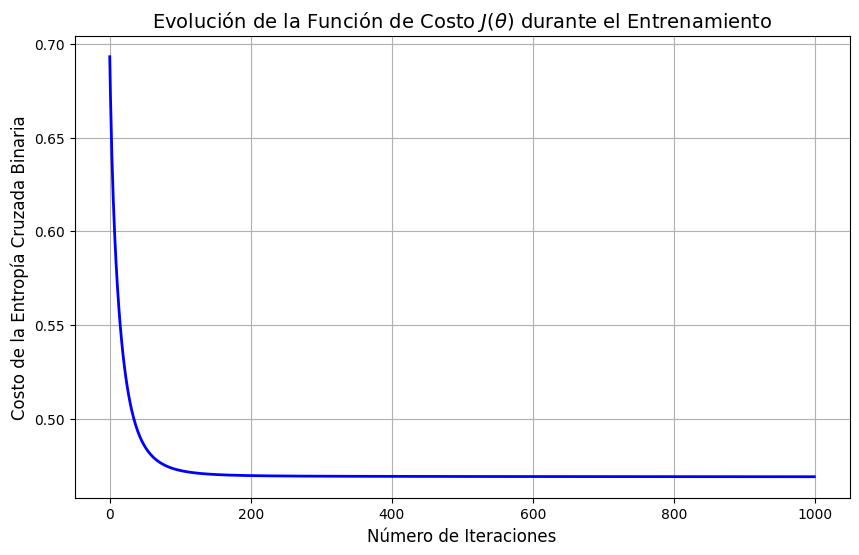

In [9]:
# Configuración del tamaño de la ventana del gráfico
plt.figure(figsize=(10, 6))

# Graficamos la evolución del costo almacenado frente al número de iteraciones
plt.plot(range(len(J_history)), J_history, color='blue', linewidth=2)

# Asignación de etiquetas explicativas en los ejes y título
plt.title("Evolución de la Función de Costo $J(\\theta)$ durante el Entrenamiento", fontsize=14)
plt.xlabel("Número de Iteraciones", fontsize=12)
plt.ylabel("Costo de la Entropía Cruzada Binaria", fontsize=12)
plt.grid(True)

# Desplegar el gráfico final en pantalla
plt.show()

### Explicación de los Comandos Utilizados en la Celda Anterior:
* `plt.plot(range(len(J_history)), J_history)`: Genera una línea continua donde el eje horizontal representa el avance de las iteraciones de entrenamiento y el eje vertical muestra la disminución continua del error del modelo. Esto evidencia visualmente que el algoritmo está aprendiendo correctamente y convergiendo hacia el costo mínimo.
* `plt.grid(True)`: Inserta una cuadrícula de fondo para facilitar la lectura de las coordenadas y el análisis visual de la asíntota del costo.

In [12]:
def predecirClase(theta, X):
    # Calcula las probabilidades continuas usando la sigmoide
    probabilidades = sigmoid(X.dot(theta))
    
    # Si la probabilidad es >= 0.5 se asigna la clase 1, de lo contrario la clase 0
    predicciones = (probabilidades >= 0.5).astype(int)
    return predicciones

# Generamos predicciones para el conjunto de entrenamiento (80%) y validación (20%)
predicciones_train = predecirClase(theta_optimizado, X_train)
predicciones_test = predecirClase(theta_optimizado, X_test)

# Cálculo formal del porcentaje de precisión (Accuracy)
precision_entrenamiento = np.mean(predicciones_train == y_train) * 100
precision_validacion = np.mean(predicciones_test == y_test) * 100

print(f"Efectividad en el Conjunto de Entrenamiento (80%): {precision_entrenamiento:.2f} %")
print(f"Efectividad en el Conjunto de Validación/Prueba (20%): {precision_validacion:.2f} %")

Efectividad en el Conjunto de Entrenamiento (80%): 80.82 %
Efectividad en el Conjunto de Validación/Prueba (20%): 81.87 %


### Explicación de los Comandos Utilizados en la Celda Anterior:
* `(probabilidades >= 0.5).astype(int)`: Aplica el umbral estándar de decisión para clasificar de manera binaria. Convierte los valores booleanos resultantes (`True` / `False`) a números enteros (`1` / `0`).
* `np.mean(predicciones_test == y_test) * 100`: Compara cada una de las predicciones del modelo frente a la realidad guardada en el 20% de prueba (`y_test`). Al calcular la media aritmética de aciertos matemáticos, obtenemos la tasa de efectividad real o *Accuracy* del modelo en datos nunca antes vistos, lo cual demuestra la efectividad y validez práctica del laboratorio solicitado.

# Evaluación Detallada y Visualización de las Predicciones en el Conjunto de Entrenamiento

En esta sección, obligatoria según la guía de laboratorio, procederemos a extraer y analizar el valor numérico exacto (probabilidad de la hipótesis $h_\theta(x)$) que el modelo calcula ("vota") para cada uno de los ejemplos utilizados durante la etapa de entrenamiento. 

Esto nos permitirá observar de manera transparente cómo la función sigmoide mapea las combinaciones lineales hacia valores entre 0 y 1, y cómo se transforman en una clasificación binaria final (0 o 1) al aplicar el umbral de decisión de $0.5$. Mostraremos una tabla comparativa con los primeros ejemplos para evaluar visualmente la efectividad del modelo frente a los valores reales de la etiqueta $y$.

In [13]:
# 1. Calculamos el valor continuo (probabilidad) que "vota" el modelo para TODO el conjunto de entrenamiento
probabilidades_train = sigmoid(X_train.dot(theta_optimizado))

# 2. Convertimos esas probabilidades a una clasificación binaria (0 o 1) utilizando el umbral de 0.5
clases_predichas_train = (probabilidades_train >= 0.5).astype(int)

# 3. Construimos un DataFrame con Pandas para visualizar los resultados de forma estructurada
tabla_comparativa = pd.DataFrame({
    'Muestra Index': range(1, 11),
    'Valor de Hipótesis (Probabilidad h_theta)': probabilidades_train[:10],
    'Clase Votada por el Modelo': clases_predichas_train[:10],
    'Clase Real de Entrenamiento (y)': y_train[:10]
})

# Mostrar la tabla en la consola del cuaderno sin índices ocultos
print("=== PRIMEROS 10 EJEMPLOS DE ENTRENAMIENTO: VALORES VOTADOS VS VALORES REALES ===")
print(tabla_comparativa.to_string(index=False))

=== PRIMEROS 10 EJEMPLOS DE ENTRENAMIENTO: VALORES VOTADOS VS VALORES REALES ===
 Muestra Index  Valor de Hipótesis (Probabilidad h_theta)  Clase Votada por el Modelo  Clase Real de Entrenamiento (y)
             1                                   0.499157                           0                                1
             2                                   0.151788                           0                                1
             3                                   0.206115                           0                                0
             4                                   0.239734                           0                                0
             5                                   0.139056                           0                                0
             6                                   0.232142                           0                                0
             7                                   0.062991                           0 

### Explicación de los Comandos Utilizados en la Celda Anterior:
* `X_train.dot(theta_optimizado)`: Realiza la multiplicación matricial entre todas las muestras de entrenamiento normalizadas y el vector de parámetros óptimos $\theta$ obtenido del descenso por el gradiente. Esto calcula el valor de $z$ para cada ejemplo.
* `sigmoid(...)`: Pasa el valor de $z$ por la función de activación logística para transformarlo en una probabilidad real entre 0 y 1. Este es el "voto matemático" crudo del modelo.
* `(probabilidades_train >= 0.5).astype(int)`: Evalúa de forma vectorizada qué probabilidades cumplen con ser mayores o iguales al 50%. Los valores que cumplen se vuelven `True` (1) y los que no, `False` (0).
* `[:10]`: Técnica de *slicing* (rebanado) de NumPy que selecciona únicamente los primeros 10 elementos del arreglo para no saturar la pantalla con las 24,000 filas de entrenamiento.
* `pd.DataFrame({...})`: Estructura de Pandas que toma múltiples listas u arrays de NumPy y los organiza en columnas etiquetadas para crear una tabla limpia y profesional.
* `to_string(index=False)`: Método de Pandas que convierte el DataFrame en texto plano legible eliminando la columna automática de índices, facilitando la impresión directa en Visual Studio Code.

In [14]:
# Cálculo manual de las métricas de la matriz de confusión para evaluar la efectividad
verdaderos_positivos = np.sum((clases_predichas_train == 1) & (y_train == 1))
verdaderos_negativos = np.sum((clases_predichas_train == 0) & (y_train == 0))
falsos_positivos = np.sum((clases_predichas_train == 1) & (y_train == 0))
falsos_negativos = np.sum((clases_predichas_train == 0) & (y_train == 1))

# Impresión formal del reporte de efectividad cuantitativa sobre los datos de entrenamiento
print("=================== MATRIZ DE EVALUACIÓN DE RESULTADOS ===================")
print(f"[-] Total de ejemplos evaluados: {y_train.size}")
print(f"[+] Verdaderos Negativos (El modelo predijo correctamente que NO incumplirían): {verdaderos_negativos}")
print(f"[+] Verdaderos Positivos (El modelo predijo correctamente que SÍ incumplirían): {verdaderos_positivos}")
print(f"[!] Falsos Positivos (El modelo votó que SÍ incumplirían, pero en realidad NO): {falsos_positivos}")
print(f"[!] Falsos Negativos (El modelo votó que NO incumplirían, pero en realidad SÍ): {falsos_negativos}")
print("==========================================================================")

# Recálculo de verificación de la precisión global
precision_verificada = (verdaderos_positivos + verdaderos_negativos) / y_train.size * 100
print(f"Efectividad total calculada mediante matriz de aciertos: {precision_verificada:.2f} %")

=================== MATRIZ DE EVALUACIÓN DE RESULTADOS ===================
[-] Total de ejemplos evaluados: 24000
[+] Verdaderos Negativos (El modelo predijo correctamente que NO incumplirían): 18125
[+] Verdaderos Positivos (El modelo predijo correctamente que SÍ incumplirían): 1272
[!] Falsos Positivos (El modelo votó que SÍ incumplirían, pero en realidad NO): 505
[!] Falsos Negativos (El modelo votó que NO incumplirían, pero en realidad SÍ): 4098
Efectividad total calculada mediante matriz de aciertos: 80.82 %


### Explicación de los Comandos Utilizados en la Celda Anterior:
* `&`: Operador lógico *AND* a nivel de elementos en NumPy. Nos permite validar de manera simultánea que se cumpla la condición de la predicción y de la etiqueta real.
* `(clases_predichas_train == 1) & (y_train == 1)`: Filtra los casos donde el modelo predijo un incumplimiento de pago (1) y el cliente efectivamente cayó en mora (1). Esto se conoce técnicamente como **Verdaderos Positivos**.
* `np.sum(...)`: Al aplicar la suma sobre condiciones booleanas, NumPy trata los `True` como 1 y los `False` como 0, dándonos el conteo exacto de registros que cumplen con cada cuadrante de evaluación.
* `y_train.size`: Propiedad de NumPy que devuelve la cantidad total de elementos dentro del vector, utilizado aquí como denominador común para calcular analíticamente la tasa de efectividad general.